## Preprocessing code

In this notebook ill hold all code to do with preprocessing done to the image data to generate my dataset. This will involve:
* Extracting Pose data from video files
* Dataset Augmentations
* Sanity testing extraction pipeline


Links:
* PyTorch LSTM : docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

In [2]:
import os
import ast 
import copy
import json
import torch
import shutil
import random
import sklearn.metrics

import cv2 as cv
import numpy as np
import pandas as pd
import torch.nn as nn
# import mediapipe as mp
import matplotlib.pyplot as plt


from tqdm import tqdm
from joblib import dump, load
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Custom classes
from classes.GraphPlotting import GraphPlotter


RANDOM_STATE = 42

# Global vars ill use throughout the file
SWING_TYPES = ['Backhand', 'Forehand', 'NoStroke', 'Serves']
KEYPOINTS = ['NOSE','LEFT_EYE_INNER','LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR','RIGHT_EAR','MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST','RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE','RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'] 

Loading my GPU

In [ ]:
gpu_visible = torch.cuda.is_available()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Is my GPU visible to train on :', gpu_visible)
print('Using device:', device)
print()

# Gpu stats and optimisations 
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
    # Making deterministic
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# No random variability
random.seed(RANDOM_STATE); 
np.random.seed(RANDOM_STATE); 
torch.manual_seed(RANDOM_STATE); 

Is my GPU visible to train on : True
Using device: cuda

NVIDIA GeForce RTX 3070
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


Utility functions that I use throughout this script

In [4]:
def pretty_print_json(dict_object: object):
    ''' Makes JSON object prettier for being printed 
    '''
    json_object = json.dumps(dict_object)
    parsed_json = json.loads(json_object) 
    print(json.dumps(parsed_json, indent=4))


def save_JSON_object(json_path: str, json_object: object):
    ''' Saves a JSON Object to a path
    '''
    with open(json_path, 'w') as outfile:
        json.dump(json_object, outfile)


def load_JSON_object(json_path: str):
    ''' Loads JSON object from a file
    '''
    with open(json_path, "r") as f:
        json_data = json.load(f)
        return json_data


def create_folder(folder_name: str):
    '''Used to create folders
    '''
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)


def save_torch_model(model, save_folder: str ='models/', file_name: str = None):
    ''' Saves torch models 
    Args:
        model (nn) : Model to be saved 
        save_folder (String) : String file path to folder where all models will be saved 
        file_name (String) : Name to save model as
    '''
    create_folder(save_folder)
    torch.save(model.state_dict(), f'{save_folder}{file_name}.pth')


## Create all pose features

In [ ]:
def create_pose_df(json_data:object):
    ''' Create a DataFrame that more mutable for generating features
    Args:
        json_data (Object) : Object containing all pose data for every frame for a given action
    Returns:
        df (pd.DataFrame) : DF containing all pose data as columns
    '''
    pose_data_dict = {f"{kp}_{axis}": [] for kp in KEYPOINTS for axis in ("X", "Y", "Z")}

    for index, frame_data in enumerate(json_data['list_body_part_points']):
        for keypoint_dict in frame_data['key_points']:
            for axis in ['x', 'y', 'z']:
                pose_data_dict[f'{keypoint_dict["part"]}_{axis.upper()}'].append(keypoint_dict[axis])
            
    df = pd.DataFrame(pose_data_dict)
    return df



def generate_extra_keypoints(df:pd.DataFrame):
    ''' Function to create a set of new keypoints using KP's generated from the pose mdoel
    Args:
        df (DataFrame) : DF conatining all X,Y,Z for all keypoints
    Returns:
        df (DataFrame) : DF with new feature columns added
    '''
    # Calcualte center of hips
    df['MID_HIP_X'] = (df['RIGHT_HIP_X'] + df['LEFT_HIP_X']) / 2
    df['MID_HIP_Y'] = (df['RIGHT_HIP_Y'] + df['LEFT_HIP_Y']) / 2
    df['MID_HIP_Z'] = (df['RIGHT_HIP_Z'] + df['LEFT_HIP_Z']) / 2
    # calculate center of shoulders
    df['MID_SHOULDER_X'] = (df['RIGHT_SHOULDER_X'] + df['LEFT_SHOULDER_X']) / 2
    df['MID_SHOULDER_Y'] = (df['RIGHT_SHOULDER_Y'] + df['LEFT_SHOULDER_Y']) / 2
    df['MID_SHOULDER_Z'] = (df['RIGHT_SHOULDER_Z'] + df['LEFT_SHOULDER_Z']) / 2
    # Calculate center torso
    df['MID_CENTER_TORSO_X'] = (df['RIGHT_HIP_X'] + df['MID_SHOULDER_X']) / 2
    df['MID_CENTER_TORSO_Y'] = (df['RIGHT_HIP_Y'] + df['MID_SHOULDER_Y']) / 2
    df['MID_CENTER_TORSO_Z'] = (df['RIGHT_HIP_Z'] + df['MID_SHOULDER_Z']) / 2
    return df



def translational_invariance(df:pd.DataFrame, center_point:str ="NOSE"):
    ''' Spatially align the skeleton by re-centering all keypoints around a chosen point.
    Args:
        center_point (str): The keypoint used as the origin (default: "NOSE").
    Returns:
        pd.DataFrame: DataFrame with translationally invariant pose data.
    '''
    # Extract center coordinates
    cx = df[f"{center_point}_X"]
    cy = df[f"{center_point}_Y"]

    # Subtract center from all X and Y coordinate columns
    for col in df.columns:
        if col.endswith("_X"):
            df[col] = df[col] - cx
        elif col.endswith("_Y"):
            df[col] = df[col] - cy

    return df



def generate_deltas(df:pd.DataFrame):
    ''' Calculate the movement of each keypoint over a frame
    Args:
        df (DataFrame) : DF conatining all X,Y,Z for all keypoints
    Returns:
        df (DataFrame) : DF with new delta columns added
    '''
    delta_features = {f'{col}_DELTA': df[col].diff() for col in df.columns}
    df = pd.concat([df, pd.DataFrame(delta_features)], axis=1)
    # Fill first diff row with 0's
    df = df.fillna(0)
    return df



def calculate_velocities(df:pd.DataFrame, fps:float =30.0):
    ''' Take the created delta cols and convert them to velocities
    Args:
        df (DataFrame) : DF containing all feature and KP cols
        fps (Float) : frame per second of video standardised to 30
    Returns:
        df (DataFrame) : dfwith velocity columns added
    '''
    # Get all delta cols & calculate velocity for each of them
    delta_cols = [col for col in df.columns if col.endswith('_DELTA')]
    vel = df[delta_cols] * fps
    vel.columns = [col.replace('_DELTA', '_VELO') for col in vel.columns]
    df = pd.concat([df, vel], axis=1)
    return df


def calculate_acceleration(df:pd.DataFrame, fps:float =30.0):
    ''' Calculate Acceleration from velocities
    Args:
        df (DataFrame) : DF containing all feature and KP cols
        fps (Float) : frame per second of video standardised to 30
    Returns:
        df (DataFrame) : DF with acceleration columns added
    '''
    velo_cols = [col for col in df.columns if col.endswith('_VELO')]
    acc = df[velo_cols].diff() * fps
    acc.columns = [c.replace('_VELO', '_ACC') for c in acc.columns]
    df = pd.concat([df, acc.fillna(0)], axis=1)
    return df



def calculate_vector_direction(df:pd.DataFrame, origin_kp:str, traget_kp:str):
    ''' Function to calculate the direction of the vector from origin_kp to the target_kp
    Args:
        Args:
        df (DataFrame) : DF containing all feature and KP cols
        origin_kp (String) : Origin KP name
        targte_kp (String) : Target KP name
    Returns:
        df (DataFrame) : DF with X,Y & Z direction columns added
    '''
    wrist_side = traget_kp.split('_')[0]
    # Get diffs from origin to target
    dx = df[f'{traget_kp}_X'] - df[f'{origin_kp}_X']
    dy = df[f'{traget_kp}_Y'] - df[f'{origin_kp}_Y']
    dz = df[f'{traget_kp}_Z'] - df[f'{origin_kp}_Z']

    # Vector magnitude (per frame)
    mag = np.sqrt(dx**2 + dy**2 + dz**2)
    # Vector overlap
    mag = mag.replace(0, np.nan)

    # Direction unit vector components
    df[f'DIR_TORSO_{wrist_side}_WRIST_X'] = dx / mag
    df[f'DIR_TORSO_{wrist_side}_WRIST_Y'] = dy / mag
    df[f'DIR_TORSO_{wrist_side}_WRIST_Z'] = dz / mag
    return df


def get_most_front_plane(df:pd.DataFrame):
    ''' Function for calculating the frme where the pose skeleton is most aligned with the 
        frontal plane for finding the most optimal frame for scaling the skeleton
    Args:
        df (DataFrame) : DF containing all feature and KP cols
    Returns:
        A scaled DF 
    '''
    df['HIP_Z_DIFF'] = (df["RIGHT_HIP_Z"] - df["LEFT_HIP_Z"]).abs()
    df['SHOULDER_Z_DIFF'] = (df["RIGHT_SHOULDER_Z"] - df["LEFT_SHOULDER_Z"]).abs()
    df['AVG_Z_DIFF'] = (df['HIP_Z_DIFF'] + df['SHOULDER_Z_DIFF']) / 2

    gp = GraphPlotter('')
    min_diff = df['AVG_Z_DIFF'].min()
    min_idx = df['AVG_Z_DIFF'].idxmin()
    print(min_diff)
    print(min_idx)
    gp.plot_kp_over_time({'AVG_Z_DIFF' : df['AVG_Z_DIFF']}, 'AVG_Z_DIFF')
    print("-"* 50)
    
    return df



def scale_invariance(df:pd.DataFrame, ref:str ='both'):
    ''' Usede to scale all skeletons to the same size
    Args:
        df (DataFrame) : DF containing all feature and KP cols
    '''
    df = get_most_front_plane(df)



def calculate_torso_to_wrist_vector(df:pd.DataFrame):
    ''' Calculate the direction of the vector from the center of the torso to each arm
    Args:
        df (DataFrame) : DF containing all feature and KP cols
    Returns:
        df (DataFrame) : DF with direction vector X,Y,Z columns added for each torso to arm vector
    '''
    df = calculate_vector_direction(df, 'MID_CENTER_TORSO', 'LEFT_WRIST')
    df = calculate_vector_direction(df, 'MID_CENTER_TORSO', 'RIGHT_WRIST')
    return df



def calculate_wrist_distance(df:pd.DataFrame):
    ''' Calculate the distance between the wrists
    Args:
        df (DataFrame) : DF containing all feature and KP cols
    Returns:
        df (DataFrame) : DF with wrist euclidean distance column added
    '''
    df['WRIST_DIST_X'] = abs(df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])
    df['WRIST_DIST_Y'] = abs(df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])
    # 2D euclidean distance
    df['WRIST_EUCLID_DIST'] = np.sqrt((df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])**2 + (df['RIGHT_WRIST_Y'] - df['LEFT_WRIST_Y'])**2)
    return df


def generate_features(file_path:str, subset_cols:list):
    ''' Main function where I generate all of the features ill use for my model
    Args:
        file_path (String) : String file path to JSON file we want ot generate features for 
        subset_cols (List) : List of keypoints that will be removed
    '''
    # print('File Path:', file_path)
    # NOTE - Recomputs all JSON files and extract FPS of each instead of standardising to 30
    json_data = load_JSON_object(file_path)
    
    # Convert dict to DF
    df = create_pose_df(json_data)
    
    # Generate all extra keypoints that I think will be useful for when I start training or that can be used to generate features
    df = generate_extra_keypoints(df)

    # Center origin around pose skeleton
    df = translational_invariance(df, center_point='MID_HIP')

    # NOTE - Used for scaling the skeleton
    # scale_invariance(df, ref='both')
    # df = get_most_front_plane(df)

    # Calculate keypoint movement between frames
    df = generate_deltas(df)

    # Calculate velocities
    df = calculate_velocities(df, fps=30)

    df = calculate_acceleration(df, fps=30)

    # calculate the distance between wrists -  should help with splitting 
    df = calculate_wrist_distance(df)

    # Calculate direction of vectors from center of the torso to each wrist
    df = calculate_torso_to_wrist_vector(df)

    # Remove any cols I dont want to be included when forming the GMM's
    if subset_cols:
        cols_to_remove = get_cols_to_remove(df)
        df = df[[i for i in df.columns if i not in cols_to_remove]]
    
    # COnvert to numpy array
    feature_array = df.to_numpy(dtype=np.float32)
    feature_array = np.nan_to_num(feature_array, nan=0.0, posinf=0.0, neginf=0.0)
    col_list = df.columns
    return feature_array, col_list


def get_cols_to_remove(df:pd.DataFrame):
    ''' Removing columns i think wont be actually useful for generating GMM's
    Args:
        df (DataFrame) : DF containing all columns some of which we will remove
    Args:
        cols_to_remove (List) : List of columns we will remove
    '''
    nonimportant_keypoints = ['NOSE', 'EYE', 'THUMB', 'MOUTH', 'EAR', 'PINKY', 'THUMB', 'INDEX', 'HEEL', 'FOOT', 'ANKLE', 'KNEE', '_DELTA']
    cols_to_remove = [i for i in df.columns if '_Z' in i or any(substr in i for substr in nonimportant_keypoints)]
    # for i in cols_to_remove:
    #     print(i)
    return cols_to_remove



def create_action_JSON_dataset(files_list:list, base_folder:str, output_folder:str, desc:str='Working...'):
    ''' Takes a list of files and opens their JSON files and creates a series ofgenerated features to add
    Args:
        files_list (List) : List of files we want to generate features for 
        base_folder (String) : File path to folder containing all JSON files for all file name sin files_list
        output_folder (String) : String file path to folder we want to save the output JSON file to
        file_name (String) : Name of output file
        desc (String) : Description for tqdm
    Returns:
        col_list (List) : List of cols that will  be used further down
        saves JSON file where {K = swing_type : V = {file_name : np.ndarray of data}}
    '''
    # List of cols
    col_list = []

    # Create folder to store all numpy arrays and features
    create_folder(output_folder)
    # Function for building all features ill be using as a base for all of my models 
    train_data = {'Backhand': [], 'Forehand': [], 'Serves': [], 'NoStroke': []}
    for file_name in tqdm(files_list, desc=desc):
        
        # Create feature columns and return as numpy array with list of remaining columns
        feat_array, col_list = generate_features(f'{base_folder}{file_name}', subset_cols=True)

        if "BH" in file_name:
            train_data['Backhand'].append((file_name, feat_array))
        elif "FH" in file_name:
            train_data['Forehand'].append((file_name, feat_array))
        elif "SV" in file_name:
            train_data['Serves'].append((file_name, feat_array))
        elif "NS" in file_name:
            train_data['NoStroke'].append((file_name, feat_array))

    
    # NOTE - save each swing action type to its own file
    for swing_type, tuple_list in train_data.items():
        uids  = np.array([uid for uid, _ in tuple_list])
        swing_data = np.array([data for _, data in tuple_list], dtype=object)
        np.savez_compressed(f'{output_folder}{swing_type}.npz', uid=uids, swings=swing_data)

    return col_list


# NOTE - Creates JSON file in output_folder where K == action and V == dict where {K == file && V == np.ndarray of pose data} 
create_folder('data/json_data/npz/')
# Instead of stratifying ymself I can use train_test split 
all_files = os.listdir('data/json_data/merged/')

# Create folder of all files
col_list = create_action_JSON_dataset(files_list=all_files, 
                           base_folder='data/json_data/merged/', 
                           output_folder='data/json_data/npz/all/', 
                           desc='Genereating Train set features')

Genereating Train set features: 100%|██████████| 200/200 [00:06<00:00, 28.66it/s]


In this cell Im looking at the length of each file so I can see what length sliding window is appropriate
Already kind of have this from preprocesing, will start with 60 frames but will see if I should move it down

In [8]:
frame_lens = []
for file_name in os.listdir('data/json_data/npz/all/'):
    swing_data = np.load(f'data/json_data/npz/all/{file_name}', allow_pickle=True)
    action_dict = swing_data['swings']
    for sample in action_dict:
        frame_lens.append(sample.shape[0])


print('Total swings:', len(frame_lens))
print('Max length:', max(frame_lens))
print('Min length:', min(frame_lens))
print('Mean length:', np.mean(frame_lens))

Total swings: 200
Max length: 78
Min length: 56
Mean length: 58.63


links:
* np.savez_compressed : https://numpy.org/doc/2.2/reference/generated/numpy.savez_compressed.html
* g4g LSTM : https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/
* LSTM docs : https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
* MLMastery Multi LSTM : https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

* Sequence length : https://stackoverflow.com/questions/49573242/what-is-sequence-length-in-lstm
* Sequence length for action recognition : https://www.sciencedirect.com/science/article/pii/S2468227623002521


Plan:
* Start by taking the whole 2 second clips as our sequence length as baseline
    * use dataset as i got it 
* Split NoStroke into 'other movement' and 'idle / ready position' class and retrain

Need to differenciat between 'other Movement' class and idel / ready position class


NoStroke files that contains the start of a swing:
* NS_25
* NS_26
* NS_30
* NS_31
* NS_32
* NS_33
* NS_35
* NS_36
* NS_38 (Start of serve but might be ok)?


Idle files:
* NS_20
* NS_27
* NS_28
* NS_29
* NS_37
* NS_39
* NS_40

In [ ]:
''' 
    Links:
        scaling before padding : https://stackoverflow.com/questions/61264448/in-a-lstm-should-normalization-be-done-before-or-after-the-split-in-train-and-te
'''
def load_swing_data(npz_folder_path:str):
    ''' Load all saved npz files into X_train and y_train
    Args:
        npz_folder_path (String) : Folder path to fodler containing all swing .npz files
    Returns:
        X_train (List) : Feature training data
        y_train (List) : Label training data
        file_names (List) : Corresponding file name to the index of each sample in X_train & y_train
    '''
    X_train = []
    y_train = []
    file_names = []
    for file_name in os.listdir(npz_folder_path):
        class_name = file_name.split(".")[0]
        swing_data = np.load(f'{npz_folder_path}{file_name}', allow_pickle=True)
        action_dict = swing_data['swings']
        uids = swing_data['uid']
        for i in range(0, len(action_dict)):
            X_train.append(action_dict[i])
            y_train.append(class_name)
            file_names.append(uids[i])
    
    return X_train, y_train, file_names




def split_dataset(X_data:list, y_data:list):
    ''' Split total dataset into stratified train / valid / test split
    Args:
        X_data (List) : All X data
        y_data (List) : All y data
    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test
    '''
    X_train, X_tmp, y_train, y_tmp = train_test_split(X_data, y_data, test_size=0.3, stratify=y_data, random_state=RANDOM_STATE)
    X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=RANDOM_STATE)
    return X_train, X_val, X_test, y_train, y_val, y_test




def scale_train_dataset(X_train:list):
    ''' Scale dataset values to same size so acceleeration/velocity doesnt amplify noise
    Args:
        X_train (Array) : List of arrays im scaling
    Returns:
        X_train (Array) : Array of scaled arrays
        scaler (StandardScaler) : Scaler used on X_train
    '''
    scaler = StandardScaler()
    X_train_stacked = np.vstack(X_train)
    scaler.fit(X_train_stacked)
    X_train_scaled = [scaler.transform(x).astype(np.float32) for x in X_train]
    return X_train_scaled, scaler



def apply_train_scaler(X_data, scaler:StandardScaler):
    ''' Applying the scaler made form X_train to the rest of the data
    Args:
        transfomed X_data (List) : X_data that is now in the same scale as the training data
    '''
    return [scaler.transform(x).astype(np.float32) for x in X_data]



def data_preprocessing(X_train:list, y_train:list, window_len:int, show:bool =False):
    ''' Used to pad each sample to the same size for the LSTM and encode labels from strings to Ints
    Args:
        X_train (List) : 
        y_train (List) : 
        window_len (Int) : The size of the wonfow lenfth we'll be using based on dataset EDA
        show (Bool) : Used to sanity test my preprocessing or not
    Returns:
        X_padded (List) : X_train but now all samples are the same length
        y_int_classes (List) : y_train but now all swing types are [0, 1, 2, 3]
    '''
    # Load X_train into one array and pad samples smaller than window_len
    X_padded = np.zeros((len(X_train), window_len, X_train[0].shape[1]), dtype=np.float32)
    for index, sample in enumerate(X_train):
        t = min(window_len, sample.shape[0])
        X_padded[index, :t] = sample[:t]

    # Encode class names to ints from file names for crossentropyloss
    class_dict = {swing_name : index for index, swing_name in enumerate(SWING_TYPES)}
    y_int_classes = np.array([class_dict[c] for c in y_train], dtype=np.int64)
    if show:
        pretty_print_json(class_dict)#
        print('Y Classes as Int:', y_int_classes)
        print('Len Dataset:', len(y_int_classes))

    return X_padded, y_int_classes



def dataset_preprocessing_main(npz_folder_path:str, window_len:int =60):
    ''' Main function to dealing with all preprocessing steps 
    Args:
        npz_folder_path (String) : Folder path to folder containinng .npz files for all 
        window_len (Int) : The sliding window size that i use to try recognise a movement based on EDA in preprocessing
    Returns:
        X_train_scaled_padded (List) : Padded X_test
        X_val_scaled_padded (List) : Padded X_test
        X_test_scaled_padded (List) : Padded X_test
        y_train_int (List) : y_train as list of ints
        y_val_int (List) : y_val as list of ints
        y_test_int (List) : y_test as list of ints
        scaler (StandardScaler) : Scaler calculated using the training data
    '''
    # Load saved .npz swing data
    X_data, y_data, file_names = load_swing_data(npz_folder_path)

    # Split padded samples 
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X_data, y_data)

    # Scale dataset to deal with velocity and FPS values
    # NOTE Need to remove either delta or Velo becuase theyre colinear
    X_train_scaled, scaler = scale_train_dataset(X_train)
    X_val_scaled  = apply_train_scaler(X_val, scaler)
    X_test_scaled = apply_train_scaler(X_test, scaler)

    # Pad samples so theyre all the same length
    X_train_scaled_padded, y_train_int = data_preprocessing(X_train_scaled, y_train, window_len)
    X_val_scaled_padded, y_val_int = data_preprocessing(X_val_scaled, y_val, window_len)
    X_test_scaled_padded, y_test_int = data_preprocessing(X_test_scaled, y_test, window_len)

    return X_train_scaled_padded, X_val_scaled_padded, X_test_scaled_padded, y_train_int, y_val_int, y_test_int, scaler



window_len = 60
npz_all_folder_path = 'data/json_data/npz/all/'
X_train, X_val, X_test, y_train, y_val, y_test, scaler = dataset_preprocessing_main(npz_all_folder_path, window_len=window_len)

## Training pipeline

In this section is where ill define:
* A simple data loader pipeline for the dataset to take the splitt dataset from above cell
* My LSTM model Acrhitecture
* My training pipeline

In [ ]:
class SwingDataset(Dataset):
    def __init__(self, X_list, y_ids, dtype=torch.float32):
        self.X = X_list
        self.y = y_ids
        self.dtype = dtype

    def __len__(self): 
        return len(self.X)
    
    def __getitem__(self, i):
        x = self.X[i]
        if not torch.is_tensor(x):
            x = torch.as_tensor(x, dtype=self.dtype)
        else:
            x = x.to(self.dtype)
        y = int(self.y[i])
        return x, y


def load_dataset(X_train, X_valid, X_test, y_train, y_valid, y_test, batch_size=16):
    ''' 
    Args:
        X_train (List) : X_train
        X_valid (List) : X_valid
        X_test (List) : X_test
        y_train (List) :  y_train
        y_valid (List) : y_valid
        y_test (List) : y_test
        batch_size (Int) : number of samples per batch
    Returns:
        train_dataset (SwingDataset) : Custom dataset object for X_train
        val_dataset (SwingDataset) : Custom dataset object for X_val
        test_dataset (SwingDataset) : Custom dataset object for X_test
        train_loader (DataLoader) : DataLoader for X_train
        val_loader (DataLoader) : DataLoader for X_val
        test_loader (DataLoader) : DataLoader for X_test
    '''
    # Create dataset
    train_dataset = SwingDataset(X_train, y_train)
    val_dataset = SwingDataset(X_valid, y_valid)
    test_dataset = SwingDataset(X_test, y_test)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False, persistent_workers=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False)
    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader


# Load datasets
# X_train_scaled_padded, X_val_scaled_padded, X_test_scaled_padded, y_train_int, y_val_int, y_test_int, scaler
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = load_dataset(X_train, X_val, X_test, y_train, y_val, y_test)

LSTM Architecture

In [ ]:
'''
Links:
    bidirectional LSTM : https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

'''
class LSTMClassifier(nn.Module):
    ''' LSTM with option of analsying bidirectionaly
    '''
    def __init__(self, input_dim, hidden=128, num_classes=4, dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden, batch_first=True, bidirectional=bidirectional)
        # Change output dimensions if we're using bidirectional == True
        out_dim = hidden
        if bidirectional:
            out_dim = hidden * 2
        
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        ''' Forward pass
        Args:
            x (Tensor) : Input tensor
        Returns:
            out (Tensor) : logits
        '''
        _, (h_n, _) = self.lstm(x)
        
        # If bidirectional combine both states
        if self.lstm.bidirectional:
            forward_h  = h_n[-2]
            backward_h = h_n[-1]
            h = torch.cat((forward_h, backward_h), dim=1)
        # Or just take last layer
        else:
            h = h_n[-1]

        out = self.head(h)
        return out

## Training loop

In [ ]:
def train_model(model, epochs: int, device, train_loader, val_loader, train_size, val_size, batch_size:int =64,lr: float =0.003, weight_decay: float =0.0001, patience: int =5, min_delta: float =1e-3, save_best: bool =False, best_save_dir:str = None):
    ''' Training loop
    Args:
        model (Object) : Model architecture being trained
        epochs (Int) : Num epochs to train for 
        device_type (String) : Device being trained on either 'cuda' or 'cpu'
        batch_size (Int) : Num samples per batch
        lr (Float) : Learning rate 
        weight_decay (Float) : Float udner for regularisation
        patience (Int) : Num epochs we weait for improvment before stopping
        min_delta=1e-4 (Float) : Minimum improvement needed for patience to be reset
    Returns:
        model (Model) : Trained model
        training_history (Dict) : Dict where K == metric && V == List containing metrics value over training epochs
    '''
    # Define the loss function, optimizer & scheduler to decrease leanring rate
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05) # label_smoothing to try reduce variance in my validation loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    
    # Training stats collection
    training_history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "train_f1": [],   "val_f1": []
    }
    # Early stopping variables
    best_val_loss = float("inf")
    epochs_without_improve = 0
    # Store best version copy to save best performing weights in case it gets worse while waiting for patience to expire
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f'Epoch: {epoch + 1}/{epochs}')
        model.train()

        train_preds = []
        full_y_train = []
        running_val_loss = 0.0
        running_train_loss = 0.0
        running_val_corrects = 0
        running_train_corrects = 0
        
        for i, (X_train, y_train) in tqdm(enumerate(train_loader), desc=f'Epoch: {epoch}'):
            X_train = X_train.to(device, non_blocking=True)
            y_train = y_train.to(device, non_blocking=True)
            
            # Calculate loss
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Compute statistics
            running_train_loss += loss.item() * X_train.size(0)
            running_train_corrects += torch.sum(torch.argmax(outputs, dim=1) == y_train)
            
            t_preds = torch.argmax(outputs, dim=1)
            train_preds.extend(t_preds.detach().cpu().tolist())
            full_y_train.extend(y_train.detach().cpu().tolist())
        
        # Compute statistics for the entire epoch
        epoch_train_loss = running_train_loss / train_size
        epoch_train_acc = running_train_corrects.item() / train_size * 100
        epoch_train_f1_macro = sklearn.metrics.f1_score(full_y_train, train_preds, average = 'macro')
        
        # Save history stats
        training_history["train_loss"].append(epoch_train_loss)
        training_history["train_acc"].append(epoch_train_acc)
        training_history["train_f1"].append(epoch_train_f1_macro)

        # Evaluation on validation set
        val_preds = []
        full_y_val = []
        model.eval()
        with torch.no_grad():
            for X_val, y_val in val_loader:
                # Move to gpu 
                X_val = X_val.to(device, non_blocking=True)
                y_val = y_val.to(device, non_blocking=True)
                
                # Calculate val loss
                val_outputs = model(X_val)
                val_loss = criterion(val_outputs, y_val)
                v_preds = torch.argmax(val_outputs, dim=1)
                val_preds.extend(v_preds.detach().cpu().tolist())
                full_y_val.extend(y_val.detach().cpu().tolist())

                # Compute statistics
                running_val_loss += val_loss.item() * X_val.size(0)
                running_val_corrects += torch.sum(torch.argmax(val_outputs, dim=1) == y_val)

        # Compute statistics for the entire epoch
        epoch_val_loss = running_val_loss / val_size
        epoch_val_acc = running_val_corrects.item() / val_size * 100
        epoch_val_f1_macro = sklearn.metrics.f1_score(full_y_val, val_preds, average='macro')
        # Reduce lr
        scheduler.step(epoch_val_loss)

        # Store history
        training_history["val_loss"].append(epoch_val_loss)
        training_history["val_acc"].append(epoch_val_acc)
        training_history["val_f1"].append(epoch_val_f1_macro)
    
        print(f'Epoch {epoch+1}/{epochs} \n   Training Loss: {epoch_train_loss:.4f}, Training Accuracy: {epoch_train_acc:.2f}%, Training F1 Macro: {epoch_train_f1_macro:.2f}% \
            \n   Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.2f}%, Validation F1 Macro: {epoch_val_f1_macro:.2f}%' )
        

        # Patience tracking before stopping
        # NOTE ToDo: Also need to add early stopping to avoid overfitting 
        if epoch_val_loss < best_val_loss - min_delta:
            prev_best = best_val_loss
            best_val_loss = epoch_val_loss
            epochs_without_improve = 0
            best_state = copy.deepcopy(model.state_dict())
            if save_best:
                torch.save({
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        "best_val_loss": best_val_loss,
                    },
                    best_save_dir,
                )
            print(f"Improved from {prev_best:.5f} --> {best_val_loss:.5f}. Resetting patience")
        else:
            epochs_without_improve += 1
            print(f"No improvement ({epochs_without_improve}/{patience}).")

            if epochs_without_improve >= patience:
                print(f"Early stopping triggered (patience={patience}).")
                break
    
    # Loading the best states weights 
    model.load_state_dict(best_state)
    return model, training_history

Iterate over choice of having bidirectional = True or False and comapre model results

In [ ]:
input_dims = X_train[0].shape[1]
print(input_dims)
# input_dims = 73 (Used for test set)

73


In [ ]:
''' 
Links:
    Best eval metrics for LSTM : https://codesignal.com/learn/courses/time-series-forecasting-with-lstms/lessons/evaluating-and-visualizing-lstm-model-performance
    LSTM example : https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/
'''
batch_size=16
train_size = len(train_dataset)
val_size = len(val_dataset)

bi_dict = {
    'LSTM_Bidirectional_True' : True,
    'LSTM_Bidirectional_False' : False
}

# Get input dimension dims
input_dims = X_train[0].shape[1]

create_folder('data/models/')
create_folder('data/json_data/training_history/')
for file_name, option in bi_dict.items():
    model = LSTMClassifier(input_dim=input_dims, bidirectional=option).to(device)
    # Train model
    model, training_progression = train_model(model, 
                                                epochs=25, 
                                                device=device, 
                                                train_loader=train_loader, 
                                                val_loader=val_loader, 
                                                train_size=train_size, 
                                                val_size=val_size, 
                                                batch_size=batch_size,
                                                lr=1e-4, 
                                                weight_decay=1e-4, 
                                                min_delta=1e-3,
                                                patience=8, 
                                                save_best=False)
    
    save_JSON_object(f'data/json_data/training_history/{file_name}.json', training_progression)
    save_torch_model(model, save_folder='data/models/', file_name=file_name)
    del model


Epoch: 1/25


Epoch: 0: 9it [00:01,  7.70it/s]


Epoch 1/25 
   Training Loss: 1.3897, Training Accuracy: 25.71%, Training F1 Macro: 0.19%             
   Validation Loss: 1.3847, Validation Accuracy: 40.00%, Validation F1 Macro: 0.33%
Improved from inf --> 1.38467. Resetting patience
Epoch: 2/25


Epoch: 1: 9it [00:00, 204.84it/s]


Epoch 2/25 
   Training Loss: 1.3803, Training Accuracy: 35.71%, Training F1 Macro: 0.31%             
   Validation Loss: 1.3730, Validation Accuracy: 40.00%, Validation F1 Macro: 0.33%
Improved from 1.38467 --> 1.37301. Resetting patience
Epoch: 3/25


...

Epoch 23/25 
   Training Loss: 0.7923, Training Accuracy: 75.71%, Training F1 Macro: 0.63%             
   Validation Loss: 0.9289, Validation Accuracy: 63.33%, Validation F1 Macro: 0.53%
Improved from 0.96545 --> 0.92885. Resetting patience
Epoch: 24/25


Epoch: 23: 9it [00:00, 264.35it/s]


Epoch 24/25 
   Training Loss: 0.7410, Training Accuracy: 76.43%, Training F1 Macro: 0.63%             
   Validation Loss: 0.8961, Validation Accuracy: 60.00%, Validation F1 Macro: 0.50%
Improved from 0.92885 --> 0.89611. Resetting patience
Epoch: 25/25


Epoch: 24: 9it [00:00, 209.50it/s]

Epoch 25/25 
   Training Loss: 0.6875, Training Accuracy: 77.14%, Training F1 Macro: 0.67%             
   Validation Loss: 0.8640, Validation Accuracy: 66.67%, Validation F1 Macro: 0.55%
Improved from 0.89611 --> 0.86396. Resetting patience


## In this section ill be analysing the training process for both models

In [ ]:
def plot_train_val_comparison(training_dict, train_key, val_key, title, y_label,save_dir=None, show=False):
    ''' Generic plotting function to plot train VS validation results
    Args:
        model_name (String) : Name of model who's features are being plotted
        training_dict (Dict) : Dict with K == features name && V == their progression over epochs
        train_key (String) : Key for train measure to plot
        val_key (String) : Key for validation measure to plot
        title (String) : Title
        y_label (String) : Y-Axis label
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    plt.plot(training_dict[train_key])
    plt.plot(training_dict[val_key])
    plt.title(title)
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_dir:
        plt.savefig(f'{save_dir}{title}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def plot_feature_across_trainings(model_performance_dict: dict, feature_name: str=None, y_label: str=None, save_dir=None, show=False, plot_val=True):
    ''' Function to plot training performance of a specific feature across mutliple training of models with different model architectures
    Args:
        model_performance_dict (Object) : Dict object holding all training data for all models
        feature_name (String) : Key name of feature we want to plot for all models
        varied (String) : Training variable from setup that vary
        varied (String) : Training variable from setup that are fixed
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    model_names = []
    for model_name, train_dict in model_performance_dict.items():
        plt.plot(train_dict[feature_name], label=model_name)
        model_names.append(model_name)

    title = f"{feature_name.capitalize()} comparison for {' vs '.join(model_names)}"
    print(title)
    # Graph setup
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(feature_name)
    plt.legend(title="Models")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    if save_dir:
        graph_save_path = f'{save_dir}{feature_name}.png'
        plt.savefig(f'{save_dir}{feature_name}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def create_summay_df(training_histories_path):
    ''' creates a DF of the last value in each training metric for all queried models
    Args:
        training_histories_path (String) : String file path to folder
    Returns:
        summary_df (pd.DataFrame) : Summary DF of all trainin histories
    '''
    final_metrics = []
    for file_name in os.listdir(training_histories_path):
        training_data = load_JSON_object(f'data/json_data/training_history/{file_name}')
        final_metrics.append({
            "model": file_name.replace('.json', ''),
            "final_train_acc": training_data["train_acc"][-1],
            "final_val_acc": training_data["val_acc"][-1],
            "final_val_loss": training_data["val_loss"][-1],
            "final_val_f1": training_data["val_f1"][-1],
        })
    summary_df = pd.DataFrame(final_metrics)
    summary_df["generalisation_gap"] = summary_df["final_train_acc"] - summary_df["final_val_acc"]
    return summary_df



def compare_specific_models(model_list:list, training_history_folder_path:str, plot_output_folder:str):
    ''' Compare these tow if i need to
    Args:
        model_list
        training_history_folder_path
    '''
    # Load all training history data
    training_data = {model_name : load_JSON_object(f'{training_history_folder_path}{model_name}.json') for model_name in model_list}
    # print(training_data)
    plot_feature_across_trainings(training_data, feature_name='train_loss', y_label='Loss', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_acc', y_label='Accuracy', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_f1', y_label='train_f1', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)

    # Plotr training progression for all graphs
    for model_name, training_history in training_data.items():
        create_folder(f'{plot_output_folder}{model_name}/')
        # Plot accuracy
        plot_train_val_comparison(training_history, train_key='train_acc', val_key='val_acc', title=f'{model_name.replace("_", " = ")} Accuracy', y_label='Accuracy', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot loss
        plot_train_val_comparison(training_history, train_key='train_loss', val_key='val_loss', title=f'{model_name.replace("_", " = ")} Loss', y_label='Loss', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot f1 macro
        plot_train_val_comparison(training_history, train_key='train_f1', val_key='val_f1', title=f'{model_name.replace("_", " = ")} F1 Macro', y_label='F1 Macro', save_dir=f'{plot_output_folder}{model_name}/', show=True)


In this cell ill call all of the plotting functionality above

Train_loss comparison for LSTM_Bidirectional_True vs LSTM_Bidirectional_False


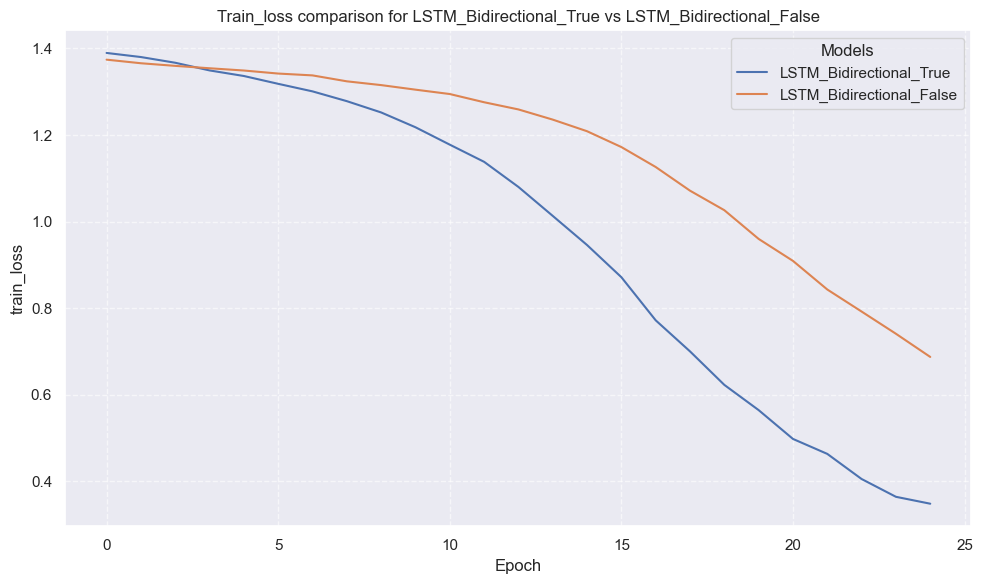

Train_acc comparison for LSTM_Bidirectional_True vs LSTM_Bidirectional_False


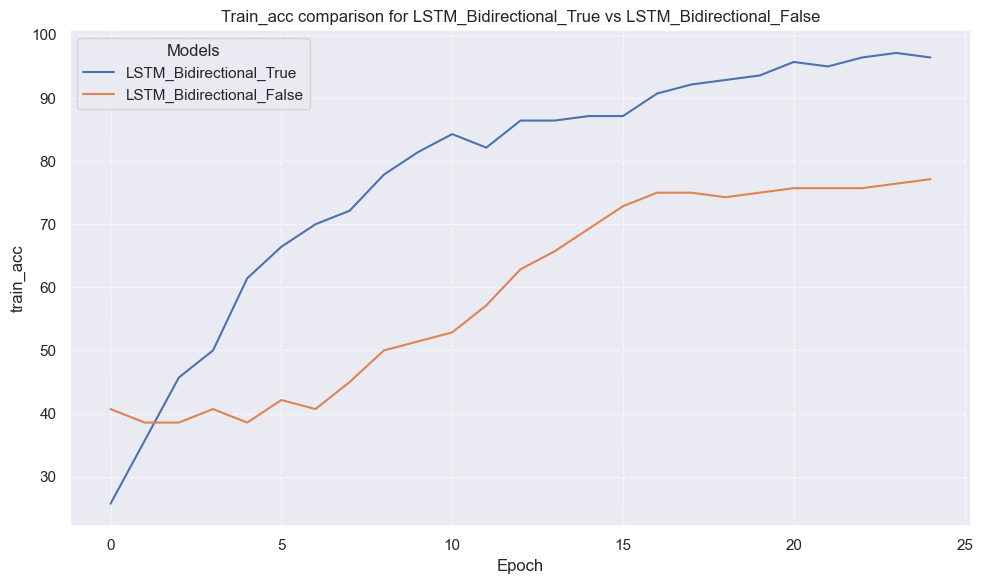

Train_f1 comparison for LSTM_Bidirectional_True vs LSTM_Bidirectional_False


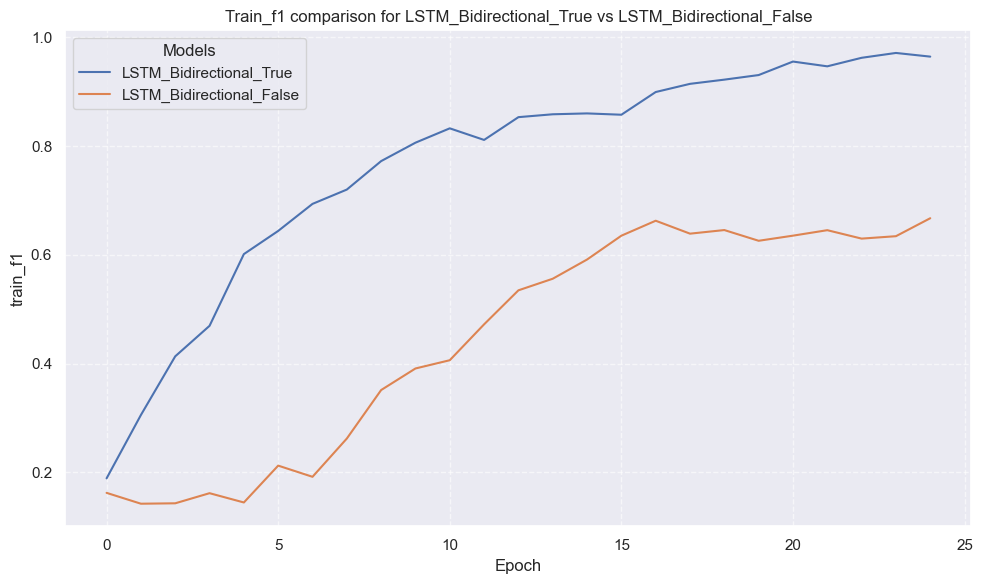

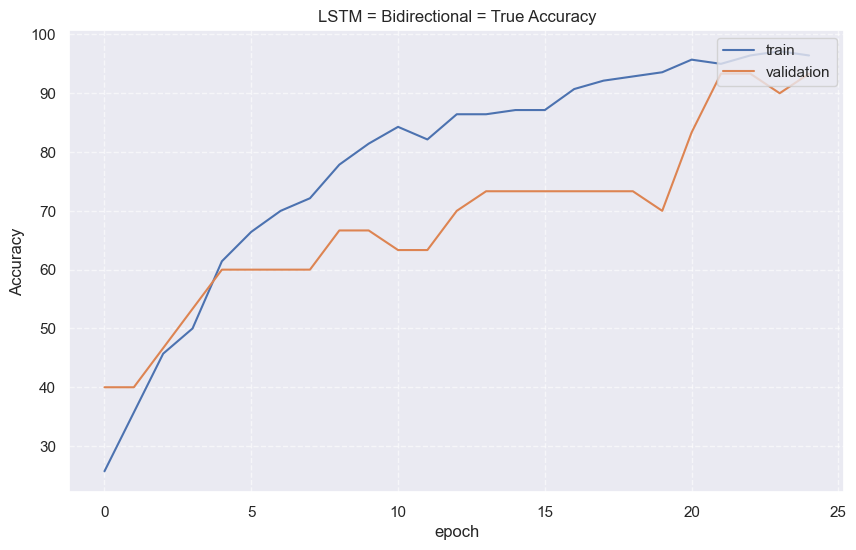

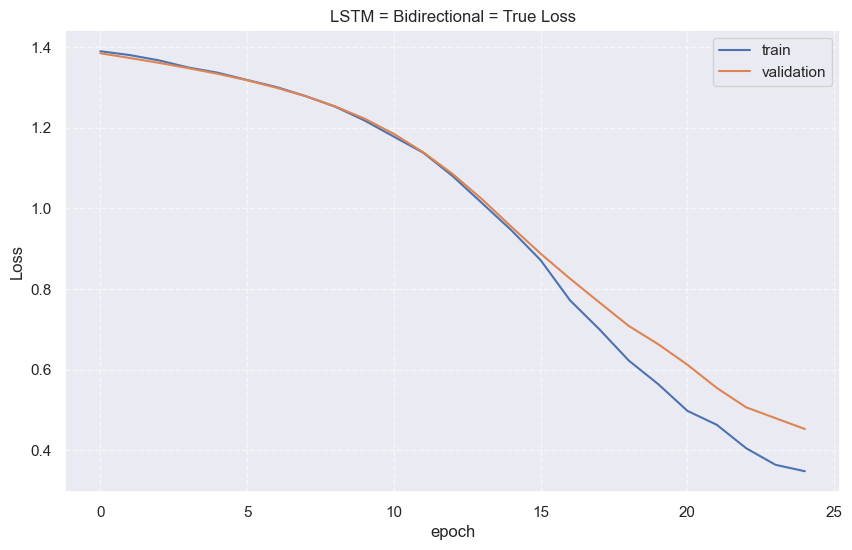

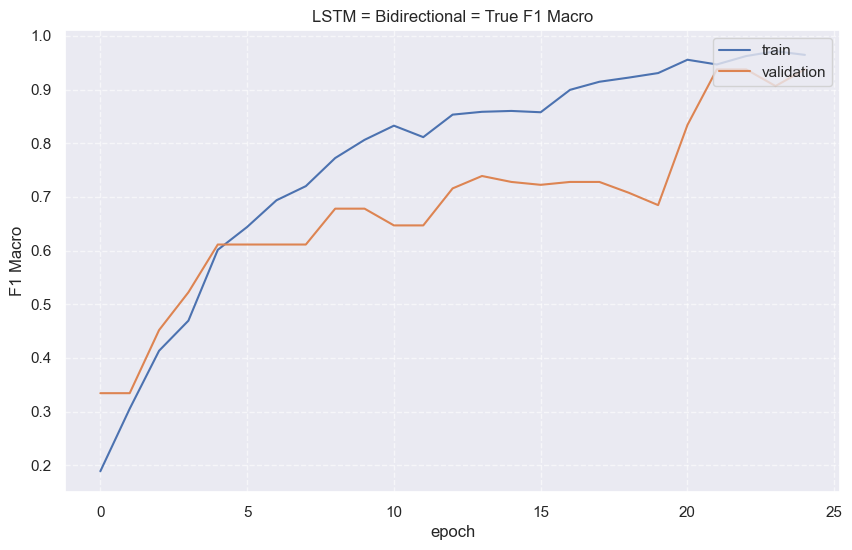

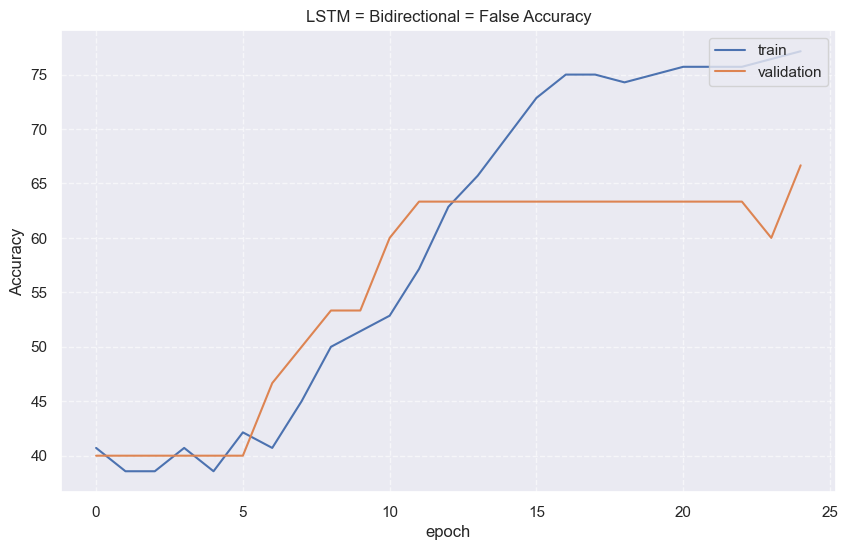

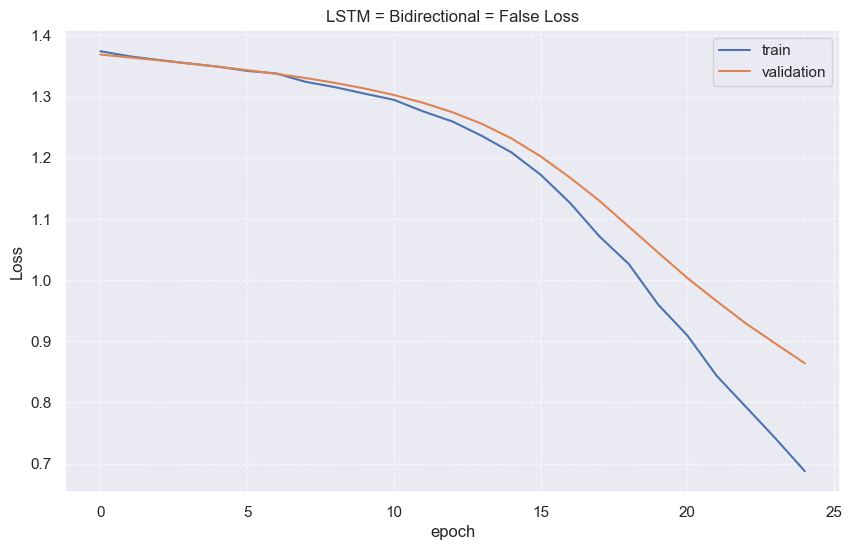

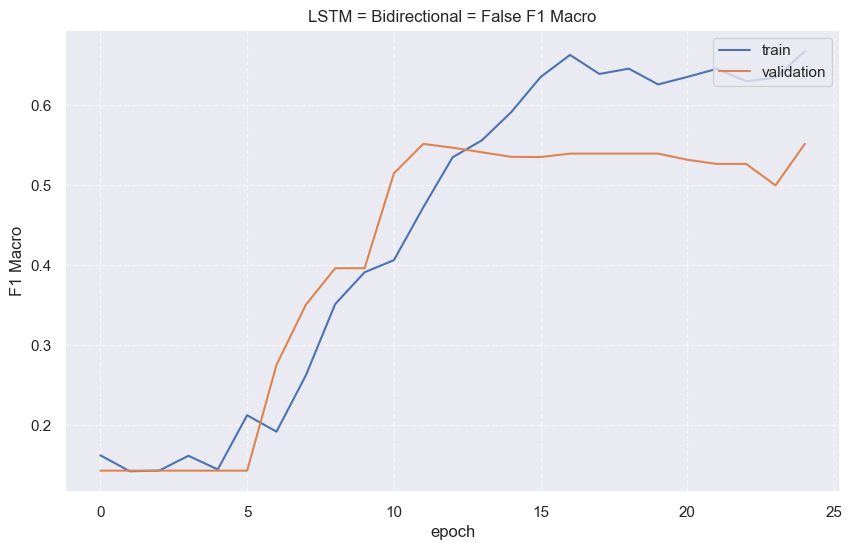

In [15]:
# Models to compare
specific_models = ['LSTM_Bidirectional_True', 'LSTM_Bidirectional_False']

plot_output_folder = 'data/graphs/'
comparison_folder = 'data/graphs/model_comparison/'
training_history_folder_path = 'data/json_data/training_history/'
create_folder('data/csv/')
create_folder(comparison_folder)
create_folder(plot_output_folder)

# Plot comparisons of training metrics
compare_specific_models(specific_models, training_history_folder_path, plot_output_folder)

# Create summary fo final results for eahc model in query
summary_df = create_summay_df(training_history_folder_path)
summary_df.to_csv('data/csv/LSTM_summary_df.csv')


LSTM_Bidirectional_False.pth
Test Accuracy: 0.633
Test F1 Macro: 0.514

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand      0.444     0.667     0.533         6
    Forehand      0.545     1.000     0.706         6
    NoStroke      0.900     0.750     0.818        12
      Serves      0.000     0.000     0.000         6

    accuracy                          0.633        30
   macro avg      0.472     0.604     0.514        30
weighted avg      0.558     0.633     0.575        30



C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

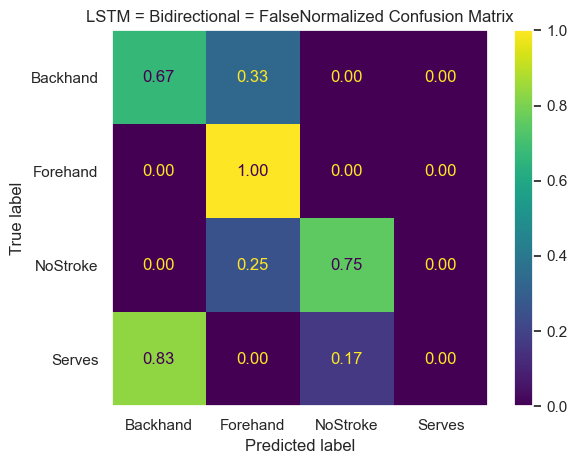

LSTM_Bidirectional_True.pth
Test Accuracy: 0.900
Test F1 Macro: 0.893

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand      1.000     0.667     0.800         6
    Forehand      0.750     1.000     0.857         6
    NoStroke      0.917     0.917     0.917        12
      Serves      1.000     1.000     1.000         6

    accuracy                          0.900        30
   macro avg      0.917     0.896     0.893        30
weighted avg      0.917     0.900     0.898        30



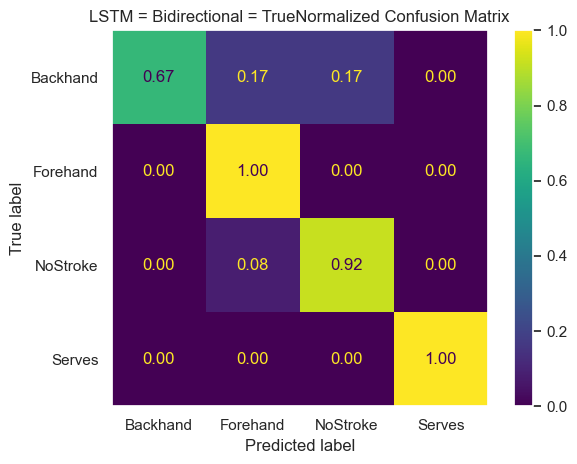

In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

bi_dict = {
    'LSTM_Bidirectional_True' : True,
    'LSTM_Bidirectional_False' : False
}
# For swap out int labels for confusion matrix
class_dict = {index : swing_name for index ,swing_name in enumerate(SWING_TYPES)}


def inference_test_set(test_loader, model):
    ''' Iterate thorugh test set and get model outputs
    Args:
       test_loader () : 
       model () :
    '''
    pred_list = []
    label_list = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            pred_list.extend(preds.cpu().numpy())
            label_list.extend(y_batch.cpu().numpy())

    return pred_list, label_list

    

def get_test_accuracy(pred_list:list, label_list:list, show=True):
    ''' Calculate the accuracy and f1 score of the model on the test set
    Args:

    '''
    test_acc = accuracy_score(label_list, pred_list)
    test_f1  = f1_score(label_list, pred_list, average='macro')
    if show:
        print(f'Test Accuracy: {test_acc:.3f}')
        print(f'Test F1 Macro: {test_f1:.3f}')
    return test_acc, test_f1





def testing_main(test_loader):
    ''' Main function for evaluating the accuracy of a trained model of a hold out test set 
    Args:
        test_loader (DataLoader) : DataLoader containing test data 
    '''
    gp = GraphPlotter('')
    
    create_folder('data/metrics/')
    for model_name in [i for i in os.listdir('data/models/') if 'LSTM_Bidirectional' in i]:
        print(model_name)
        model = None
        if 'False' in model_name:
            # 73 = X_train[0].shape[1]
            model = LSTMClassifier(input_dim=73, hidden=128, num_classes=4, bidirectional=False)
        else:
            model = LSTMClassifier(input_dim=73, hidden=128, num_classes=4, bidirectional=True)

        model.load_state_dict(torch.load(f'data/models/{model_name}'))
        model.to(device)
        y_pred, label_list = inference_test_set(test_loader, model)

        y_pred_labels = [class_dict[label_int] for label_int in y_pred]
        true_labels = [class_dict[label_int] for label_int in label_list]
        test_acc, test_f1 = get_test_accuracy(y_pred, label_list, show=True)

        # Compute per-class metrics
        print("\nDetailed Classification Report:")
        print(classification_report(true_labels, y_pred_labels, digits=3))

        gp = GraphPlotter('')
        gp.plot_confusion_matrix(y_pred_labels, true_labels, title=f'{model_name.split(".")[0].replace("_", " = ") }Normalized Confusion Matrix')

        # Get length of each action in test set
        # len_actions_list = [len(x) for x in X_test]
        # gp.plot_len_vs_acc(len_actions_list, y_true=true_labels, y_pred=y_pred_labels)


testing_main(test_loader)



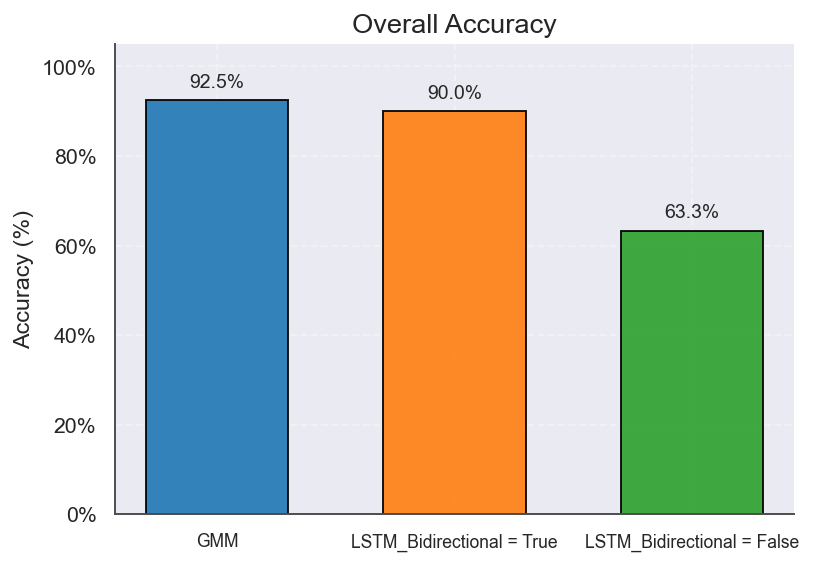

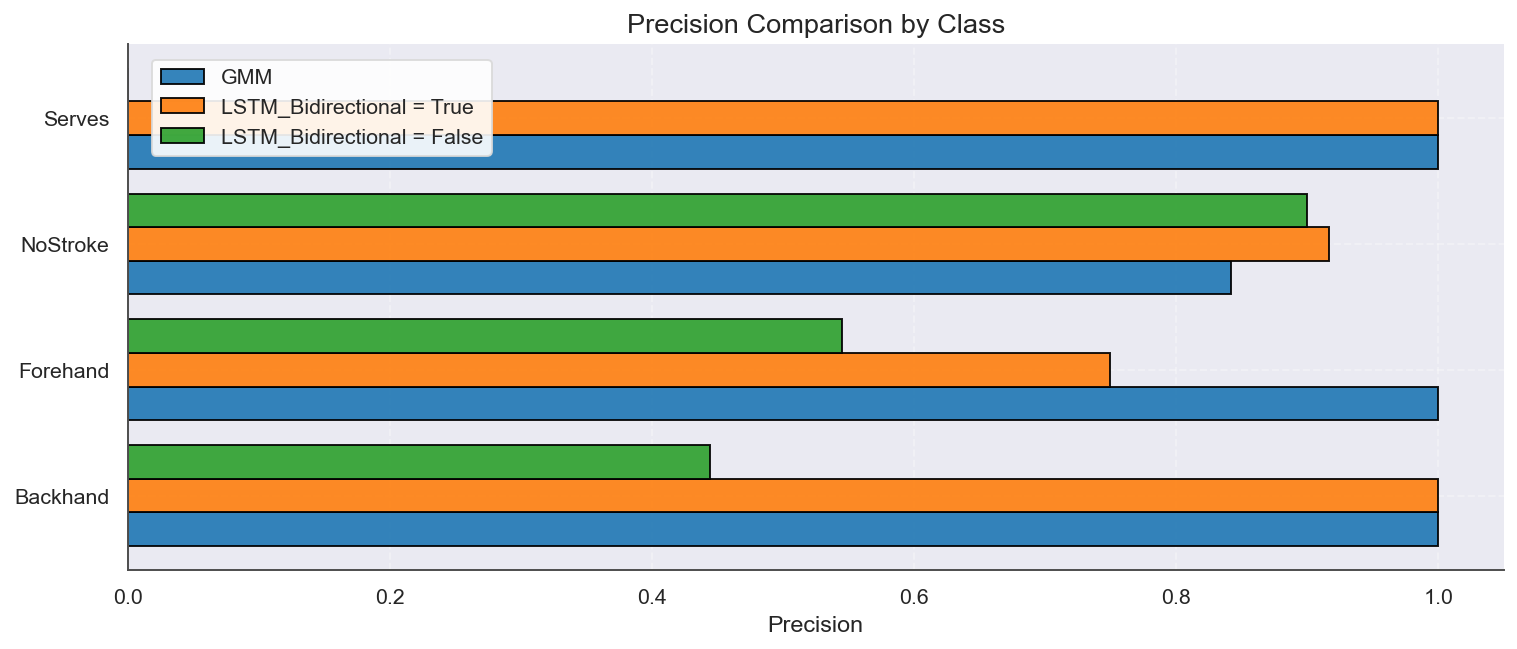

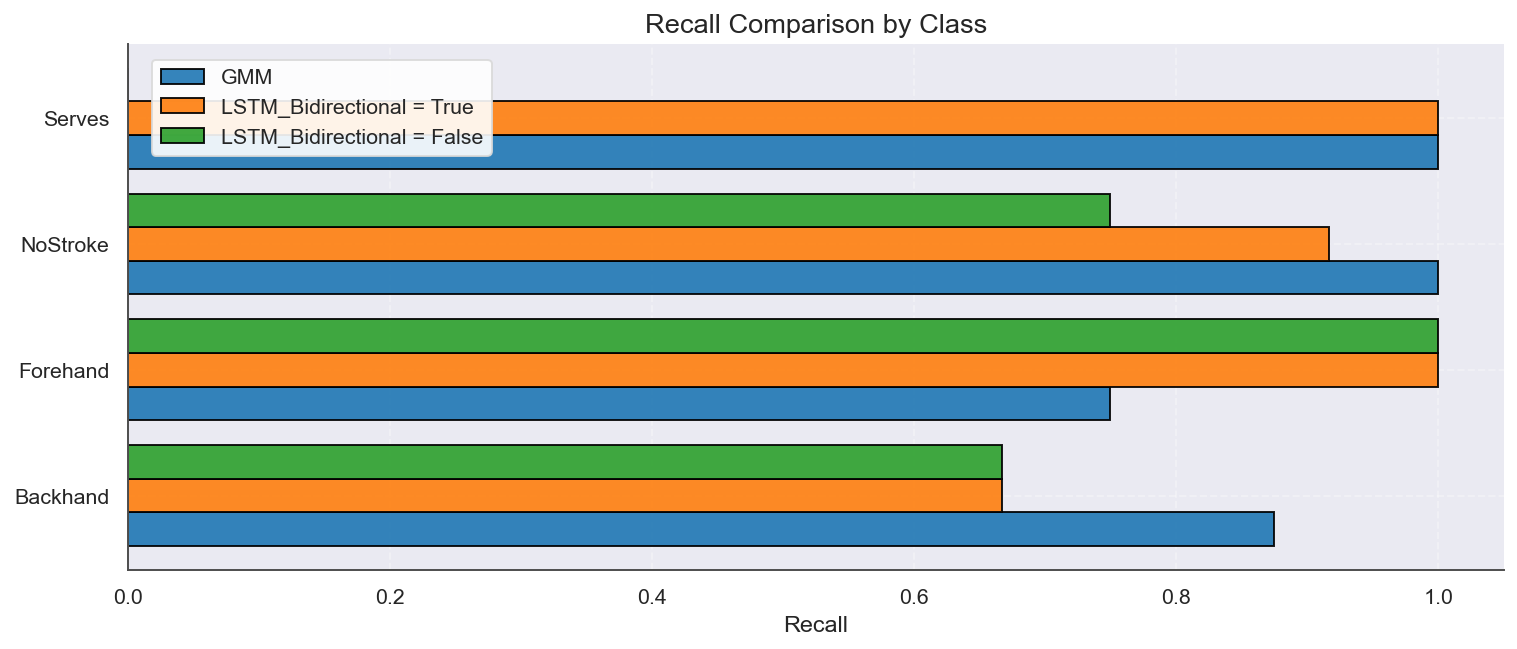

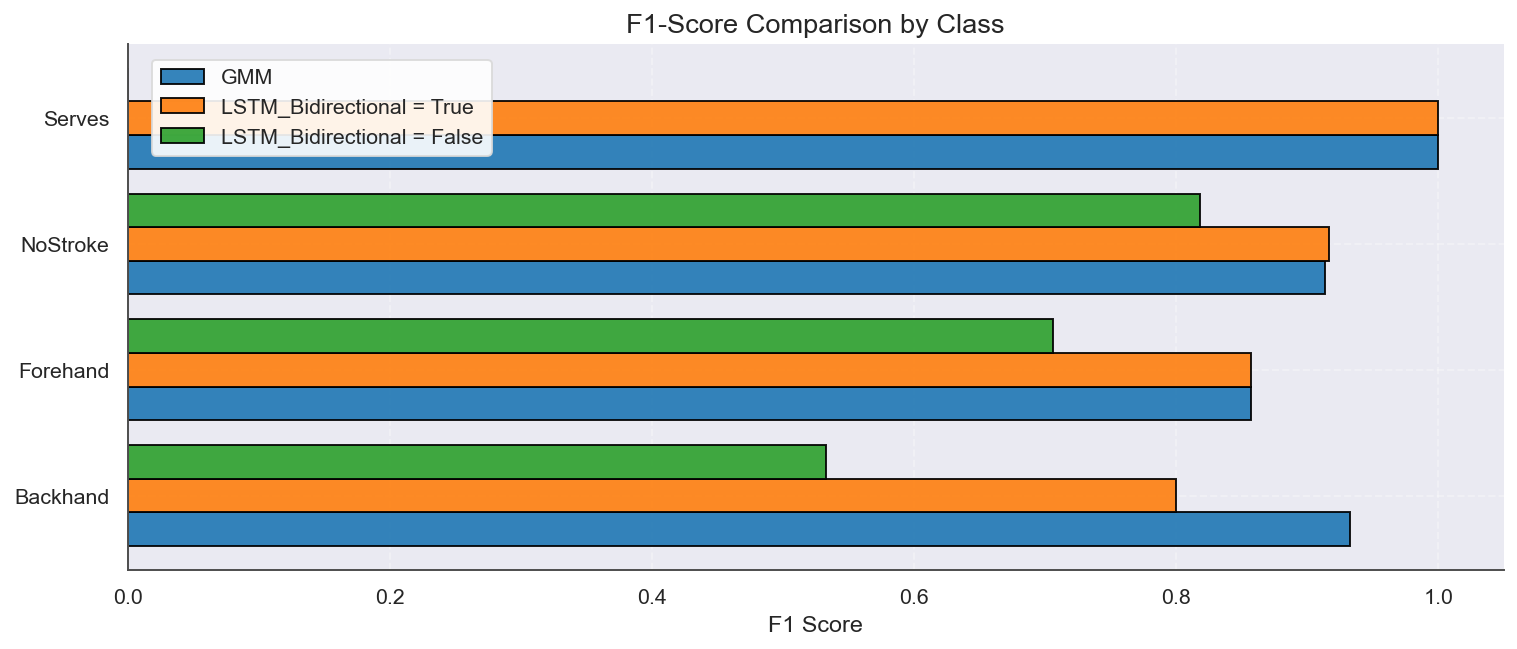

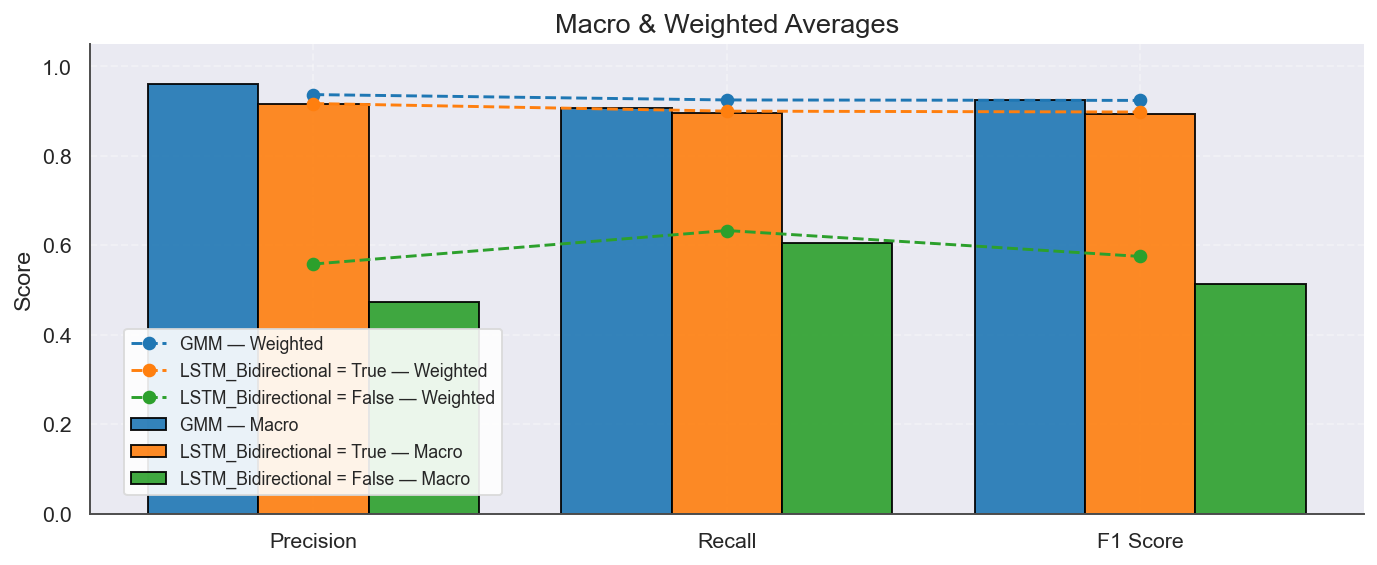

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# NOTE - RESULTS FROM ALL MODEL TRAININGS AS DICTS
GMM_results_dict = {
    "Backhand":   {"precision": 1.000, "recall": 0.875, "f1-score": 0.933, "support": 8},
    "Forehand":   {"precision": 1.000, "recall": 0.750, "f1-score": 0.857, "support": 8},
    "NoStroke":   {"precision": 0.842, "recall": 1.000, "f1-score": 0.914, "support": 16},
    "Serves":     {"precision": 1.000, "recall": 1.000, "f1-score": 1.000, "support": 8},
    "accuracy":   0.925,
    "macro avg":  {"precision": 0.961, "recall": 0.906, "f1-score": 0.926, "support": 40},
    "weighted avg": {"precision": 0.937, "recall": 0.925, "f1-score": 0.924, "support": 40}
}


bidirectional_false_results_dict = {
    "Backhand": {"precision": 0.444, "recall": 0.667, "f1-score": 0.533, "support": 6},
    "Forehand": {"precision": 0.545, "recall": 1.000, "f1-score": 0.706, "support": 6},
    "NoStroke": {"precision": 0.900, "recall": 0.750, "f1-score": 0.818, "support": 12},
    "Serves": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 6},
    "accuracy": 0.633,
    "macro avg": {"precision": 0.472, "recall": 0.604, "f1-score": 0.514, "support": 30},
    "weighted avg": {"precision": 0.558, "recall": 0.633, "f1-score": 0.575, "support": 30}
}

bidirectional_true_results_dict = {
    "Backhand": {"precision": 1.000, "recall": 0.667, "f1-score": 0.800, "support": 6},
    "Forehand": {"precision": 0.750, "recall": 1.000, "f1-score": 0.857, "support": 6},
    "NoStroke": {"precision": 0.917, "recall": 0.917, "f1-score": 0.917, "support": 12},
    "Serves": {"precision": 1.000, "recall": 1.000, "f1-score": 1.000, "support": 6},
    "accuracy": 0.900,
    "macro avg": {"precision": 0.917, "recall": 0.896, "f1-score": 0.893, "support": 30},
    "weighted avg": {"precision": 0.917, "recall": 0.900, "f1-score": 0.898, "support": 30}
}


total_results_dict = {
    'GMM' : GMM_results_dict,
    'LSTM_Bidirectional = True' : bidirectional_true_results_dict,
    'LSTM_Bidirectional = False' : bidirectional_false_results_dict
}



def plot_accuracy(total_results_dict: dict, title: str = "Overall Accuracy", model_order:list | None = None):
    ''' Bar plot of overall accuracy for any number of models.
    Args:
        total_results_dict (Dict) : 
        title (String) : Title of plot
        model_order (List) :List for model results ot appear in
    '''
    num_models = len(model_order)
    accuracies = [float(total_results_dict[m].get("accuracy", np.nan)) for m in model_order]
    base_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    colors = (base_colors * ((num_models + 2) // 3))[:num_models]

    # Plot
    x = np.arange(num_models)
    fig, ax = plt.subplots(figsize=(max(6, 1.8 * num_models), 4.2))
    bars = ax.bar(x, accuracies, width=0.6, alpha=0.9, edgecolor="black", color=colors)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy" + (" (%)" ))
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    # Annotate bars
    for bar, val in zip(bars, accuracies):
        label = f'{v*100:.1f}%'
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, label, ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()



def get_classes(metrics_dict: dict):
    ''' List of keys to exclude from comparison
    '''
    exclude = ["accuracy", "macro avg", "weighted avg"]
    return [k for k in metrics_dict.keys() if k not in exclude]




def plot_metric_by_class(total_results_dict:dict, metric:str ="f1-score", title:str = None, xlim:tuple = (0, 1.05), model_order:list = []):
    ''' Generic function to plot model results comparisons based on a passed feature
    Args:
        total_results_dict (Dict) : 
        metric (String) : Metric being compared 
        title (String) : Title of plot
        xlim (Tuple) : X-axis bounds
        model_order (List) :List for model results ot appear in
    '''
    # Fix model order if desired; else use dict order
    model_names = model_order or list(total_results_dict.keys())
    n_models = len(model_names)

    # Common classes across all models
    common_classes = sorted(set.intersection(*[set(get_classes(r)) for r in total_results_dict.values()]))

    # Collect metric values per model
    values = np.array([[total_results_dict[m][c][metric] for c in common_classes] for m in model_names])

    # Plot
    y = np.arange(len(common_classes))
    bar_width = 0.8 / n_models
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    fig, ax = plt.subplots(figsize=(11, 4.8))
    for i, (model, color) in enumerate(zip(model_names, colors)):
        offset = (i - (n_models - 1) / 2) * bar_width
        ax.barh(y + offset, values[i], height=bar_width,
                label=model, color=color, edgecolor="black", alpha=0.9)

    # Axes formatting
    ax.set_yticks(y)
    ax.set_yticklabels(common_classes)
    ax.set_xlabel(metric.replace("-", " ").title())
    ax.set_xlim(*xlim)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    if title is None:
        title = f"{metric.replace('-', ' ').title()} by Class"
    ax.set_title(title)

    # Legend: top-left, pinned with bbox_to_anchor. Avoid plt.legend().
    leg = ax.legend(loc="upper left", bbox_to_anchor=(0.01, 0.99),
                    frameon=True, facecolor="white", edgecolor="0.85")
    leg.get_frame().set_alpha(0.9)

    plt.tight_layout()
    plt.show()




def plot_macro_weighted_averages(total_results_dict: dict, metrics=("precision", "recall", "f1-score"), title:str="Macro & Weighted Averages", model_order:list =None, base_colors:list = ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    ''' Plot macro-average (bars) and weighted-average (lines) metrics for all models in total_results_dict.
    Args:
        total_results_dict: {model_name: classification_report_dict, ...}
        metrics: tuple of metrics to plot ('precision', 'recall', 'f1-score')
        title: plot title
        base_colors (List) : List fo colours for each models results
    '''
    num_models = len(model_order)
    colors = (base_colors * ((num_models + 2)//3))[:num_models]
    x = np.arange(len(metrics))

    # Extract Macro and weighted values from each dict
    macro = np.array([[total_results_dict[m]["macro avg"][k] for k in metrics] for m in model_order])
    weighted = np.array([[total_results_dict[m]["weighted avg"][k] for k in metrics] for m in model_order])

    # Plot grouped marco's
    fig, ax = plt.subplots(figsize=(10, 4.2))
    bar_width = 0.8 / num_models
    for i, (name, color) in enumerate(zip(model_order, colors)):
        offset = (i - (num_models - 1)/2) * bar_width
        ax.bar(x + offset, macro[i], width=bar_width, label=f"{name} — Macro", color=color, edgecolor="black", alpha=0.9)

    # plot weighted lines
    for i, (name, color) in enumerate(zip(model_order, colors)):
        ax.plot(x, weighted[i], marker="o", linestyle="--", color=color, label=f"{name} — Weighted")

    # Axes & styling
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("-", " ").title() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # Legend: top-left inside axes
    leg = ax.legend(loc="lower left", bbox_to_anchor=(0.02, 0.02), fontsize=9, frameon=True, facecolor="white", edgecolor="0.85", ncol=1)
    leg.get_frame().set_alpha(0.9)

    plt.tight_layout()
    plt.show()



model_order_list=["GMM", "LSTM_Bidirectional = True", "LSTM_Bidirectional = False"]

# Accuracy comparison
model_names_tuple = ("Bidirectional = False", "Bidirectional = True")
plot_accuracy(total_results_dict, title="Overall Accuracy",model_order=model_order_list)

# Plot precision / recall and f1 comparison plots
plot_metric_by_class(total_results_dict, metric="precision", title="Precision Comparison by Class")
plot_metric_by_class(total_results_dict, metric="recall", title="Recall Comparison by Class")
plot_metric_by_class(total_results_dict, metric="f1-score", title="F1-Score Comparison by Class")

# Plot Macro and weighted averages
plot_macro_weighted_averages(total_results_dict, metrics=("precision", "recall", "f1-score"), title="Macro & Weighted Averages", model_order=model_order_list)

EOF